# Leafflication

This projects is an introduction to computer vision.  
It includes image data augmentation, transformation and classification.  

### Imports

In [15]:
%matplotlib inline

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

NB_REQUIRED_IMAGES = 1640

### Data distribution visualization

View image distributions on a pie and a bar chart.  

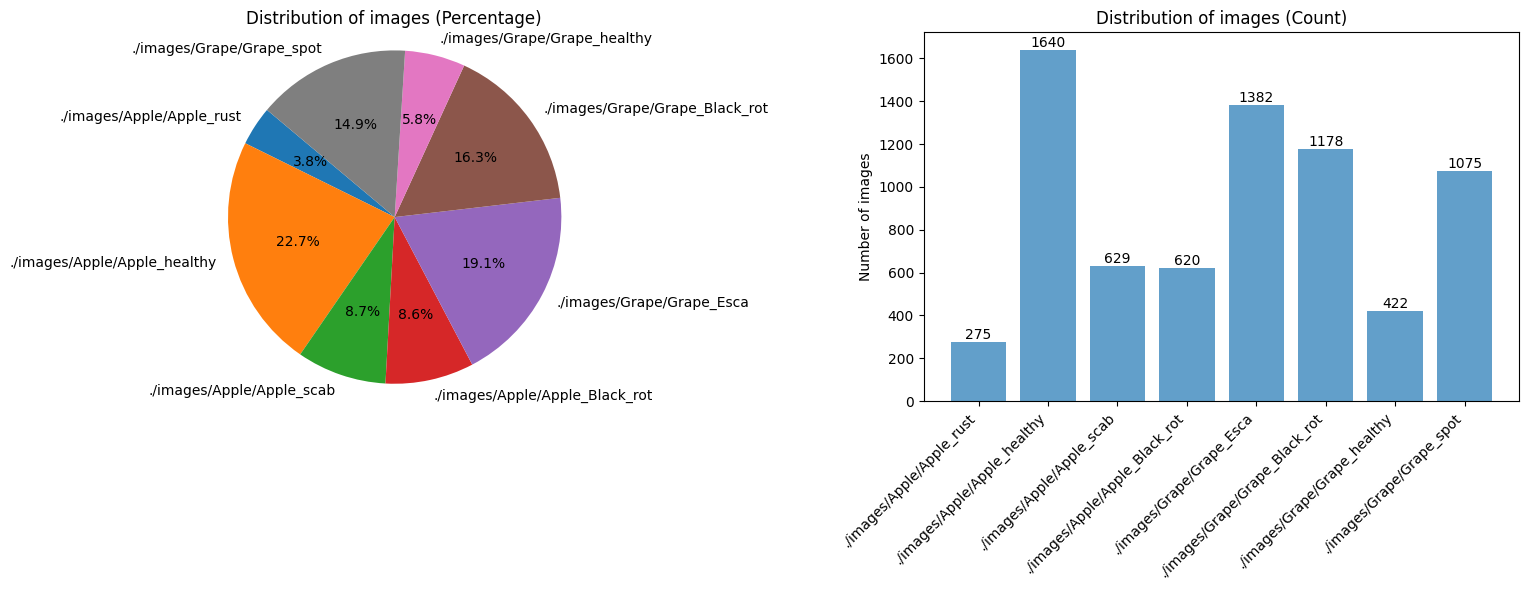

In [16]:
# APPLES_SUBDIR = './images/Apple/'
# GRAPE_SUBDIR = './images/Grape/'

APPLES_SUBDIR = './images/Apple/'
GRAPE_SUBDIR = './images/Grape/'

leaves_directory_paths = []
for sub_dir in os.listdir(APPLES_SUBDIR):
    leaves_directory_paths.append(APPLES_SUBDIR + sub_dir)
for sub_dir in os.listdir(GRAPE_SUBDIR):
    leaves_directory_paths.append(GRAPE_SUBDIR + sub_dir)

# is_not_augmented = lambda img_filename : all(sub not in img_filename for sub in IMGS_NAMES)
# get_leaves_imgs = lambda leaves_dir : [img_filename for img_filename in os.listdir(leaves_dir) if is_not_augmented(img_filename)]
get_leaves_imgs = lambda leaves_dir : [img_filename for img_filename in os.listdir(leaves_dir)]

def plot_imgs_distribution():
    # Get the list of subdirectories
    # Count the number of images in each subdirectory
    file_counts = []
    for leaf_directory_path in leaves_directory_paths:
        file_count = len(get_leaves_imgs(leaf_directory_path))
        file_counts.append(file_count)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Pie chart
    ax[0].pie(file_counts, labels=leaves_directory_paths, autopct='%1.1f%%', startangle=140)
    ax[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    ax[0].set_title("Distribution of images (Percentage)")

    # Bar chart
    y_pos = np.arange(len(leaves_directory_paths))
    bars = ax[1].bar(y_pos, file_counts, align='center', alpha=0.7)
    ax[1].set_xticks(y_pos)
    ax[1].set_xticklabels(leaves_directory_paths, rotation=45, ha='right')
    ax[1].set_ylabel('Number of images')
    ax[1].set_title('Distribution of images (Count)')

    # Annotate the bars with their respective counts
    for bar in bars:
        height = bar.get_height()
        ax[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                '%d' % int(height), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

plot_imgs_distribution()

### Data augmentation
Augment data by cropping, blurring, flipping, rotating, changing colors and applying perspective transformation

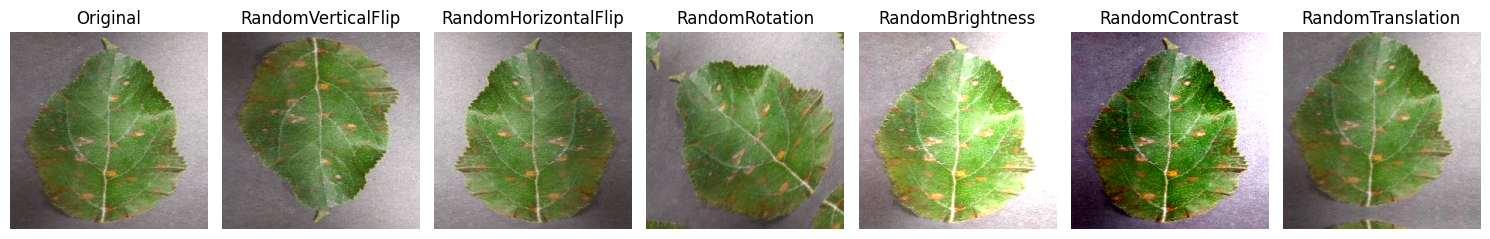

Balanced leaves images count.


In [21]:
IMGS_NAMES = [
    'Original',
    'RandomVerticalFlip',
    'RandomHorizontalFlip',
    'RandomRotation',
    'RandomBrightness',
    'RandomContrast',
    'RandomTranslation',
]

augmentations = [
  layers.RandomFlip("vertical"),
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(1),
  layers.RandomBrightness(factor=0.8),
  layers.RandomContrast(factor=1),
  layers.RandomTranslation(height_factor=0.3, width_factor=0.3),
]

def plot(imgs):
    _, axes = plt.subplots(1, len(imgs), figsize=(15, 5))
    # Convert tensor to numpy array and transpose if necessary
    # Assuming tensors are in the format CxHxW (channels, height, width)
    for i, img in enumerate(imgs):
        # transposed_img = img.numpy().transpose(1, 2, 0)
        axes[i].set_title(IMGS_NAMES[i])
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

def mk_augmentated_images(img_path, plot_imgs=False):
    og_img = tf.keras.utils.load_img(img_path)
    og_img_batch = tf.keras.utils.img_to_array(og_img)
    og_img_batch = tf.expand_dims(og_img_batch, 0)  # Create a batch
    
    imgs = [og_img]
    for augmentation, augmentation_name in zip(augmentations, IMGS_NAMES[1:]):
      augmented_img = augmentation(og_img_batch)
      augmented_img = tf.keras.utils.array_to_img(augmented_img[0])
      imgs.append(augmented_img)

      folder_path, file_name = os.path.split(img_path)
      file_name_without_extension, extension = os.path.splitext(file_name)
      new_file_path = os.path.join(folder_path, f"{file_name_without_extension}_{augmentation_name}{extension}")
      
      augmented_img.save(new_file_path)

    if plot_imgs:
        plot(imgs)

def augment_leaves_imgs(leaves_dir):
    leaves_imgs_fnames = get_leaves_imgs(leaves_dir)
    nb_og_imgs = len(leaves_imgs_fnames)
    assert nb_og_imgs > 0, "Number of leaves images in " + leaves_dir + " should be at least one."
    nb_augments = ((NB_REQUIRED_IMAGES - nb_og_imgs) // len(augmentations)) + 1
    assert nb_augments < nb_og_imgs, f"Number of leaves images({nb_og_imgs}) is inssufficient to obtain nb of required images({NB_REQUIRED_IMAGES})"
    for augment_i in range(nb_augments):
        img_fname = leaves_imgs_fnames[augment_i % nb_augments]
        mk_augmentated_images(os.path.join(leaves_dir, img_fname), plot_imgs=(augment_i == nb_augments - 1))

for leaf_directory_path in leaves_directory_paths:
    augment_leaves_imgs(leaf_directory_path)

print('Balanced leaves images count.')

### Visualize augmented images

### Images distribution after augmentation.

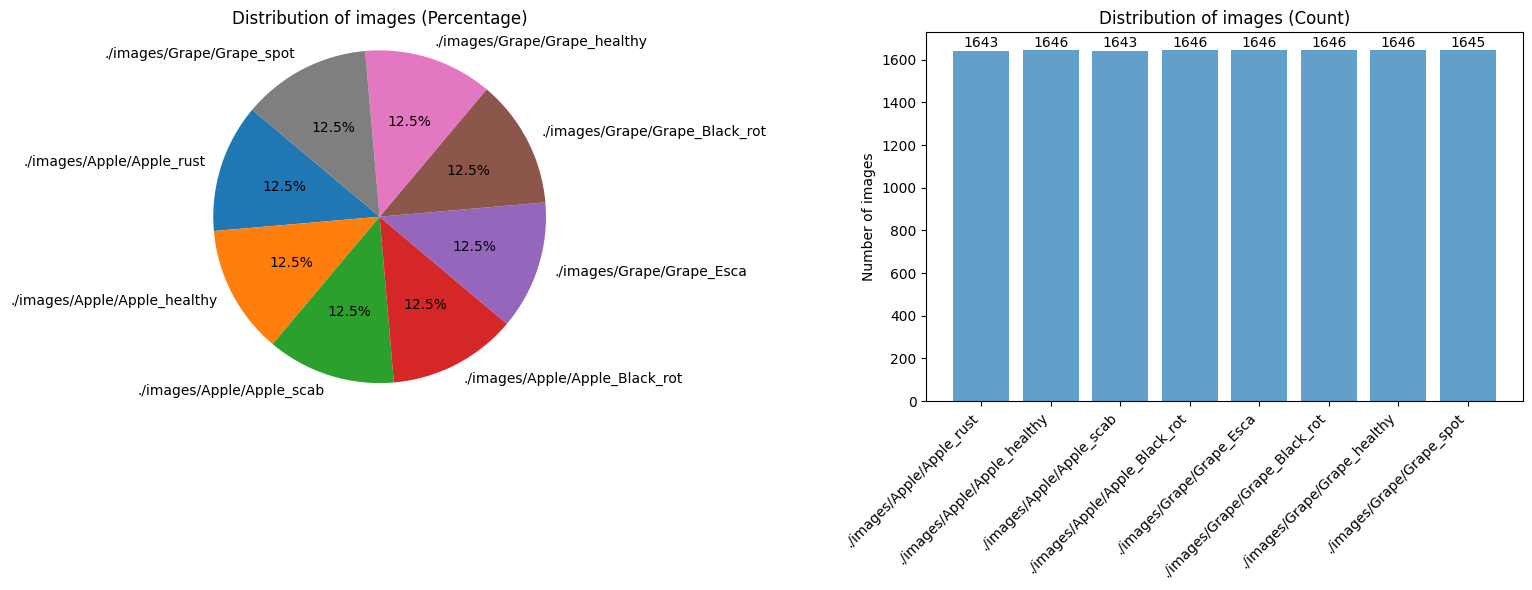

In [22]:
plot_imgs_distribution()

### Classification

Classifying the images using a CNN with the following architecture:
- conv layer of 32 8x8 filters
- Max pooling 2x2
- 64 dense layer with Relu
- 32 dense layer with Relu
- n_type of leaf dense layer with sofmax